In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
conn=duckdb.connect('aml.duckdb')

In [4]:
sns.set_theme(style='whitegrid')

In [5]:
fig_dir="."

## Visualize Class Imbalance

In [6]:
imbalance = conn.execute("""
    SELECT
        is_laundering,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4) AS pct
    FROM transactions
    GROUP BY is_laundering
    ORDER BY is_laundering
""").df()

In [7]:
imbalance

,is_laundering,count,pct
0,0,5073168,99.8981
1,1,5177,0.1019


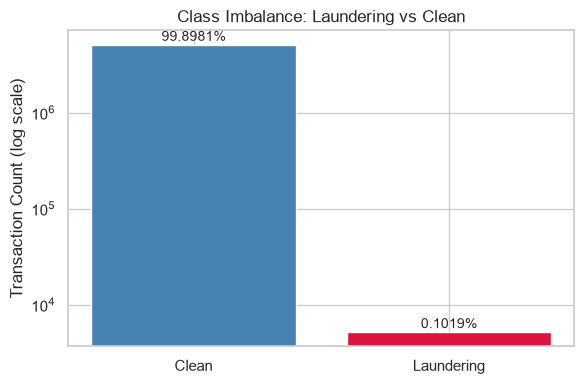

Saved: s1_class_imbalance.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    imbalance['is_laundering'].map({0: 'Clean', 1: 'Laundering'}),
    imbalance['count'],
    color=['steelblue', 'crimson']
)
ax.set_yscale('log')
ax.set_ylabel('Transaction Count (log scale)')
ax.set_title('Class Imbalance: Laundering vs Clean')
for bar, pct in zip(bars, imbalance['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1,
            f"{pct}%", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f"{fig_dir}/s1_class_imbalance.png", dpi=150)
plt.show()
print("Saved: s1_class_imbalance.png")

## AMOUNT DISTRIBUTIONS (log scale)

In [10]:
amounts = conn.execute("""
    SELECT amount_paid, is_laundering
    FROM transactions
    WHERE amount_paid > 0
""").df()

amounts['log_amount'] = np.log10(amounts['amount_paid'])

/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/1876411497.py:9: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/1876411497.py:9: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/1876411497.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(f"{fig_dir}/s2_amount_distribution.png", dpi=150)
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/1876411497.py:10: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(f"{fig_dir}/s2_amount_distribution.png", dpi=150)
/Users/touhidms/Documents/touhid_codebase/transaction_data_analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  f

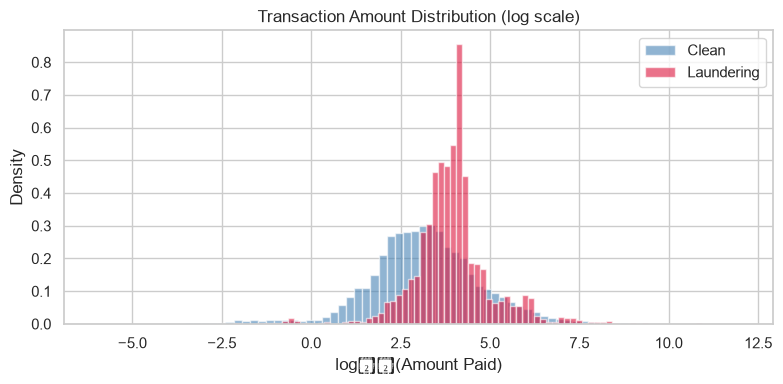

Saved: s2_amount_distribution.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, 'steelblue', 'Clean'), (1, 'crimson', 'Laundering')]:
    subset = amounts[amounts['is_laundering'] == label]['log_amount']
    ax.hist(subset, bins=80, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('log₁₀(Amount Paid)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution (log scale)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/s2_amount_distribution.png", dpi=150)
plt.show()
print("Saved: s2_amount_distribution.png")

Clean (blue) is broad and flat — legitimate transactions are spread widely across amounts, from tiny ($1) to very large ($100k+). This reflects normal economic diversity.

Laundering (red) is narrow and sharply peaked — concentrated tightly around log₁₀ ≈ 3.5–4, which is roughly $3,000–$10,000. This is not random — it's a strong signal.

Why that range? In the US, cash transactions above $10,000 trigger mandatory CTRs (Currency Transaction Reports). Structuring transactions just below $10,000 to avoid reporting is called structuring — a classic AML typology. 

In [13]:
fmt_df = conn.execute("""
    SELECT
        payment_format,
        SUM(CASE WHEN is_laundering = 1 THEN 1 ELSE 0 END)       AS laundering,
        SUM(CASE WHEN is_laundering = 0 THEN 1 ELSE 0 END)       AS clean,
        ROUND(AVG(is_laundering) * 100, 2)                       AS laundering_rate_pct
    FROM transactions
    GROUP BY payment_format
    ORDER BY laundering_rate_pct DESC
""").df()

In [14]:
fmt_df

,payment_format,laundering,clean,laundering_rate_pct
0,ACH,4483.0,596314.0,0.75
1,Bitcoin,56.0,146035.0,0.04
2,Cheque,324.0,1864007.0,0.02
3,Cash,108.0,490783.0,0.02
4,Credit Card,206.0,1323118.0,0.02
5,Reinvestment,0.0,481056.0,0.00
6,Wire,0.0,171855.0,0.00


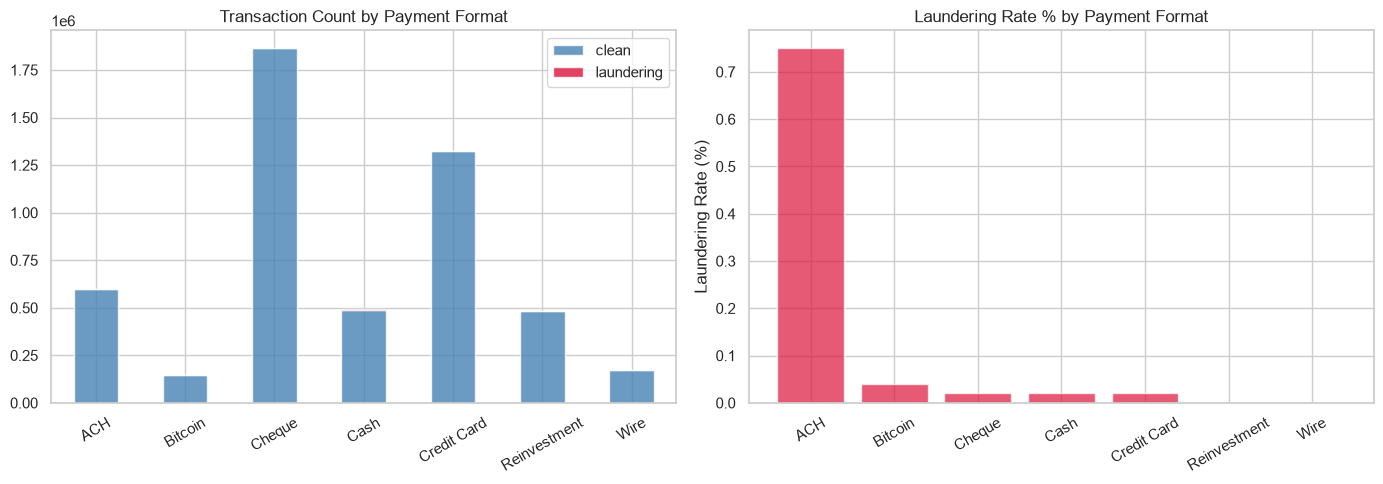

Saved: s3a_by_payment_format.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fmt_df.set_index('payment_format')[['clean', 'laundering']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['steelblue', 'crimson'], alpha=0.8
)
axes[0].set_title('Transaction Count by Payment Format')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(fmt_df['payment_format'], fmt_df['laundering_rate_pct'], color='crimson', alpha=0.7)
axes[1].set_title('Laundering Rate % by Payment Format')
axes[1].set_xlabel('')
axes[1].set_ylabel('Laundering Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{fig_dir}/s3a_by_payment_format.png", dpi=150)
plt.show()
print("Saved: s3a_by_payment_format.png")

In [18]:
ccy_df=conn.execute("""SELECT 
                            payment_currency,
                            COUNT(*) as total,
                            ROUND(AVG(is_laundering)*100,2) as laundering_rate_pct
                    FROM transactions
                    GROUP BY payment_currency
                    ORDER BY laundering_rate_pct DESC
                    LIMIT 15""").df()

In [19]:
ccy_df

,payment_currency,total,laundering_rate_pct
0,Saudi Riyal,89014,0.42
1,Euro,1168297,0.12
2,Yen,155209,0.10
3,US Dollar,1895172,0.10
4,Canadian Dollar,140042,0.09
5,Rupee,190202,0.09
6,Ruble,155178,0.09
7,Yuan,213752,0.09
8,Australian Dollar,136769,0.09
9,Mexican Peso,110159,0.08


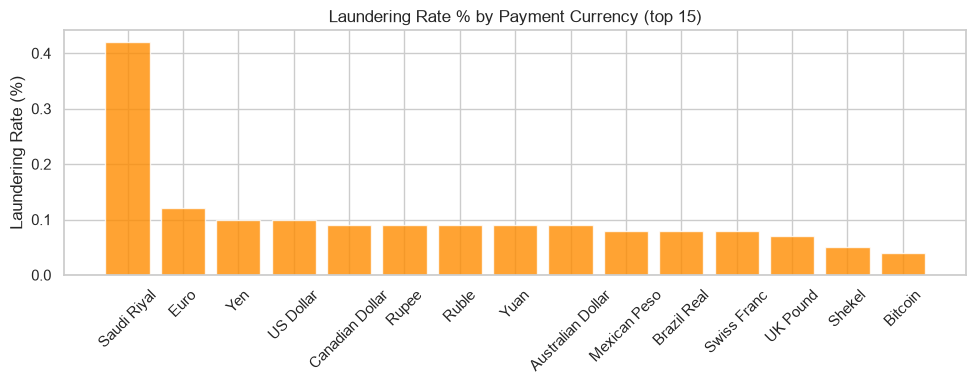

Saved: s3b_by_currency.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ccy_df['payment_currency'], ccy_df['laundering_rate_pct'], color='darkorange', alpha=0.8)
ax.set_title('Laundering Rate % by Payment Currency (top 15)')
ax.set_ylabel('Laundering Rate (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f"{fig_dir}/s3b_by_currency.png", dpi=150)
plt.show()
print("Saved: s3b_by_currency.png")

In [22]:
compare=conn.execute("""
    SELECT
        is_laundering,
        ROUND(AVG(amount_paid),2) as avg_amount,
        ROUND(MEDIAN(amount_paid),2) as median_amount,
        ROUND(MAX(amount_paid),2) as max_amount,
        COUNT(*) as tx_count
    
                     From transactions
                     GROUP BY is_laundering""").df()

In [23]:
compare

,is_laundering,avg_amount,median_amount,max_amount,tx_count
0,0,4477000.04,1410.99,1.046302e+12,5073168
1,1,36135310.41,8667.21,8.485314e+10,5177


/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/3601963994.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x='label', y='log_amount',
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/3601963994.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/3601963994.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/3601963994.py:18: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(f"{fig_dir}/s4_comparison_boxplot.png", dpi=150)
/var/folders/l5/5kp2d8n91vl3jgjhfy_1mnf00000gn/T/ipykernel_98050/3601963994.py:18: UserWarning: Glyph 8320 (\

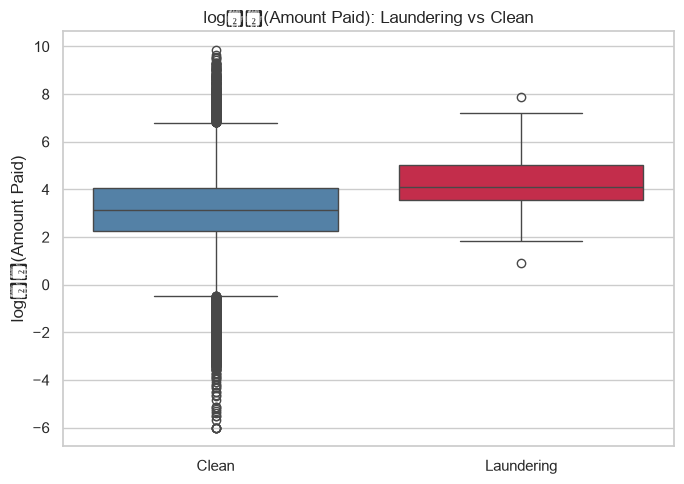

Saved: s4_comparison_boxplot.png


In [27]:
sample = conn.execute("""
    SELECT amount_paid, is_laundering
    FROM transactions
    WHERE amount_paid > 0
    USING SAMPLE 50000
""").df()

sample['label'] = sample['is_laundering'].map({0: 'Clean', 1: 'Laundering'})
sample['log_amount'] = np.log10(sample['amount_paid'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=sample, x='label', y='log_amount',
            palette={'Clean': 'steelblue', 'Laundering': 'crimson'}, ax=ax)
ax.set_title('log₁₀(Amount Paid): Laundering vs Clean')
ax.set_ylabel('log₁₀(Amount Paid)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f"{fig_dir}/s4_comparison_boxplot.png", dpi=150)
plt.show()
print("Saved: s4_comparison_boxplot.png")

## Risk CLusters

In [35]:
fanout=conn.execute("""
    SELECT from_account,
            COUNT(DISTINCT to_account) AS distinct_receivers,
            COUNT(*) as tx_count,
            MAX(is_laundering) as is_launderer
    From transactions
    GROUP BY from_account
    Order by distinct_receivers DESC""").df()
    

In [36]:
fanout

,from_account,distinct_receivers,tx_count,is_launderer
0,100428660,14230,168672,1
1,1004286A8,8846,103018,1
2,100428978,1776,20497,1
3,1004286F0,1575,18663,1
4,1004289C0,1432,16794,1
...,...,...,...,...
496990,80D181720,1,1,0
496991,80905B930,1,1,0
496992,81128DAA0,1,1,0
496993,8023F7070,1,2,0


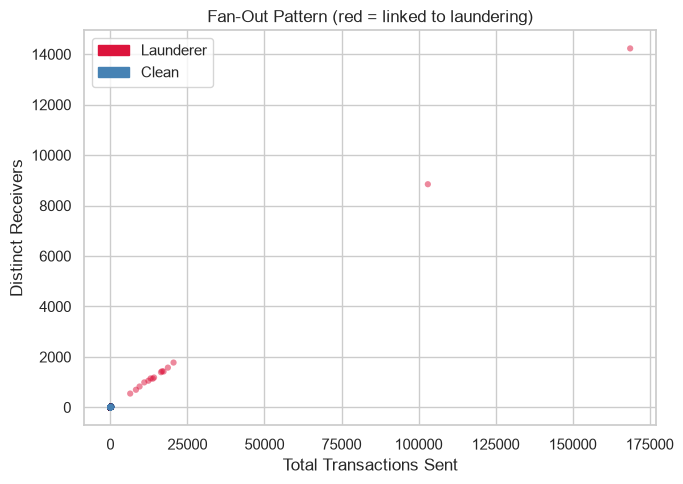

Saved: s5a_fanout.png


In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = fanout['is_launderer'].map({0: 'steelblue', 1: 'crimson'})
ax.scatter(fanout['tx_count'], fanout['distinct_receivers'],
           c=colors, alpha=0.5, edgecolors='none', s=20)
ax.set_xlabel('Total Transactions Sent')
ax.set_ylabel('Distinct Receivers')
ax.set_title('Fan-Out Pattern (red = linked to laundering)')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='crimson', label='Launderer'),
    Patch(color='steelblue', label='Clean')
])
plt.tight_layout()
plt.savefig(f"{fig_dir}/s5a_fanout.png", dpi=150)
plt.show()
print("Saved: s5a_fanout.png")

## Round amount bias analysis

In [53]:
round_amounts = conn.execute("""
    SELECT
        is_laundering,
        ROUND(SUM(CASE WHEN amount_paid % 1 = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_round
    FROM transactions
    GROUP BY is_laundering
""").df()

In [54]:
round_amounts

,is_laundering,pct_round
0,0,1.21
1,1,1.16


In [41]:
velocity=conn.execute("""
select from_account,
    CAST(timestamp as DATE) as tx_date,
                      COUNT(*) as daily_tx_count,
                      MAX(is_laundering) as is_launderer
    FROM transactions
                      GROUP BY from_account, tx_date""").df()

In [42]:
velocity

,from_account,tx_date,daily_tx_count,is_launderer
0,80F7066B0,2022-09-01,2,0
1,80B4BCB90,2022-09-01,3,0
2,8106A9530,2022-09-01,2,0
3,810C9A5A0,2022-09-01,2,0
4,810DB1AC0,2022-09-01,2,0
...,...,...,...,...
1550711,800EEE6F0,2022-09-10,3,0
1550712,80882F1D0,2022-09-10,2,0
1550713,800EBCC40,2022-09-10,2,0
1550714,807EC0840,2022-09-10,4,0


In [43]:
burst = velocity.groupby('is_launderer')['daily_tx_count'].describe()

In [44]:
burst


,count,mean,std,min,25%,50%,75%,max
is_launderer,,,,,,,,
0,1546751.0,3.004232,5.711384,1.0,1.0,2.0,4.0,2650.0
1,3965.0,108.838840,1092.161534,1.0,1.0,2.0,4.0,26365.0


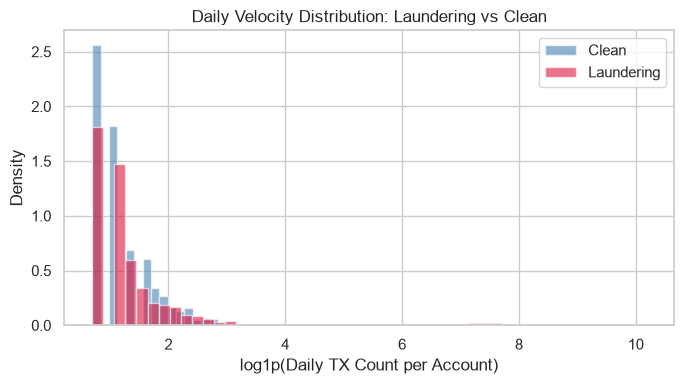

Saved: s5b_velocity.png


In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, color, name in [(0, 'steelblue', 'Clean'), (1, 'crimson', 'Laundering')]:
    subset = velocity[velocity['is_launderer'] == label]['daily_tx_count']
    ax.hist(np.log1p(subset), bins=50, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('log1p(Daily TX Count per Account)')
ax.set_ylabel('Density')
ax.set_title('Daily Velocity Distribution: Laundering vs Clean')
ax.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/s5b_velocity.png", dpi=150)
plt.show()
print("Saved: s5b_velocity.png")

## Checking data quality issues

In [46]:
cols = conn.execute("SELECT column_name FROM information_schema.columns WHERE table_name = 'transactions'").df()['column_name'].tolist()

null_checks = []
for col in cols:
    result = conn.execute(f"""
        SELECT '{col}' AS column_name,
               COUNT(*) - COUNT("{col}") AS null_count,
               ROUND((COUNT(*) - COUNT("{col}")) * 100.0 / COUNT(*), 4) AS null_pct
        FROM transactions
    """).df()
    null_checks.append(result)

nulls_df = pd.concat(null_checks, ignore_index=True)

In [47]:
nulls_df

,column_name,null_count,null_pct
0,timestamp,0,0.0
1,from_bank,0,0.0
2,from_account,0,0.0
3,to_bank,0,0.0
4,to_account,0,0.0
5,amount_received,0,0.0
6,receiving_currency,0,0.0
7,amount_paid,0,0.0
8,payment_currency,0,0.0
9,payment_format,0,0.0


## CHeck for currency msmatch

In [49]:
mismatch = conn.execute("""
    SELECT COUNT(*) AS currency_mismatch_rows
    FROM transactions
    WHERE payment_currency != receiving_currency
      AND ABS(amount_paid - amount_received) / NULLIF(amount_paid, 0) > 0.01
""").df()

In [50]:
mismatch

,currency_mismatch_rows
0,72158


## Observations

### 1. Class imbalance:
Laundering is only at 0.1019 transactions,indicating a significant class imbalance

### 2.Amount Skew:
Laundering (red) is narrow and sharply peaked — concentrated tightly around log₁₀ ≈ 3.5–4, which is roughly $3,000–$10,000. This is not random — it's a strong signal.

Why that range? In the US, cash transactions above $10,000 trigger mandatory CTRs (Currency Transaction Reports). Structuring transactions just below $10,000 to avoid reporting is called structuring — a classic AML typology. 

### 3.Payment Format risk
ACH payment method and Saudi Riyal  payment currency shows the high laundering rate vs its share wire showing minimal laundering and mahjorly clean

### 4.Fan out and Fans in
The account flagged as launders send far more to distinct receveing authorities than clean accounts

### 5. Round amount 
This bias is not applicable - instead it would be interesting to see if the transactions disproportionately cluster below certain amount or not



## Thresold - proximity

In [56]:
threshold_proximity=conn.execute("""SELECT
    is_laundering,
    ROUND(SUM(CASE WHEN amount_paid BETWEEN 8000 AND 10000 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_near_10k_threshold
FROM transactions
GROUP BY is_laundering""").df()

In [57]:
threshold_proximity

,is_laundering,pct_near_10k_threshold
0,0,2.13
1,1,4.98


### 2x times the transactions are in laundering cluster in $8k-$10k range compared to clean transactions. 